# 🧤 FIFA World Cup 2026 — Top Goalkeeper Saves Predictor
This notebook predicts which goalkeeper will make the most saves in FIFA World Cup 2026.

**Pipeline:**
1. Load & explore 2024-25 club GK data + WC 2022 GK data
2. Feature engineering
3. Train XGBoost regression model
4. Predict on 2026 squads

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
df_club    = pd.read_csv("cleaned_players_data-2024_2025.csv")
df_wc22_gk = pd.read_csv("cleaned_player_keepers.csv")
df_wc22_adv = pd.read_csv("cleaned_player_keepersadv.csv")

print(f"Club data:        {len(df_club)}")
print(f"WC 2022 GK:       {len(df_wc22_gk)}")
print(f"WC 2022 GK Adv:   {len(df_wc22_adv)}")

Club data:        2854
WC 2022 GK:       41
WC 2022 GK Adv:   41


In [3]:
df_gk = df_club[df_club["pos"].str.contains("GK", na=False)].reset_index(drop=True)
print(f"Total GKs in club data: {len(df_gk)}")
df_gk["pos"].value_counts()

Total GKs in club data: 212


pos
GK    212
Name: count, dtype: int64

In [4]:
gk_cols = ["player", "nation", "pos", "squad", "comp", "age",
           "mp_stats_keeper", "starts_stats_keeper", "min_stats_keeper",
           "ga", "ga90", "sota", "saves", "save%", "cs", "cs%",
           "pkatt_stats_keeper", "pka",
           "psxg", "psxg/sot", "psxg+/-"]

df_gk = df_gk[gk_cols].copy()

# Clean comp
clean_comps = ["eng Premier League", "es La Liga",
               "it Serie A", "de Bundesliga", "fr Ligue 1"]
df_gk = df_gk[df_gk["comp"].isin(clean_comps)].reset_index(drop=True)

# Remove zero minutes
df_gk = df_gk[df_gk["min_stats_keeper"] > 0].reset_index(drop=True)

print(f"GKs after cleaning: {len(df_gk)}")
df_gk.head()

GKs after cleaning: 212


,player,nation,pos,squad,comp,age,mp_stats_keeper,starts_stats_keeper,min_stats_keeper,ga,ga90,sota,saves,save%,cs,cs%,pkatt_stats_keeper,pka,psxg,psxg/sot,psxg+/-
0,Adrián,es ESP,GK,Betis,es La Liga,37.0,19.0,19.0,1710.0,27.0,1.42,76.0,49.0,65.8,3.0,15.8,1.0,1.0,26.0,0.33,-1.0
1,Julen Agirrezabala,es ESP,GK,Athletic Club,es La Liga,23.0,14.0,14.0,1206.0,9.0,0.67,34.0,24.0,76.5,5.0,35.7,2.0,1.0,10.5,0.27,1.5
2,Ben Alexander Voll,de GER,GK,St. Pauli,de Bundesliga,23.0,2.0,1.0,91.0,2.0,1.98,5.0,3.0,60.0,0.0,0.0,0.0,0.0,2.4,0.48,0.4
3,Alisson,br BRA,GK,Liverpool,eng Premier League,31.0,28.0,28.0,2508.0,29.0,1.04,100.0,73.0,72.0,9.0,32.1,1.0,1.0,30.5,0.30,3.5
4,Alphonse Areola,fr FRA,GK,West Ham,eng Premier League,31.0,26.0,25.0,2260.0,41.0,1.63,115.0,77.0,64.3,5.0,20.0,0.0,0.0,35.4,0.31,-2.6


In [5]:
print(df_gk["comp"].value_counts())

comp
it Serie A            49
es La Liga            45
eng Premier League    44
de Bundesliga         38
fr Ligue 1            36
Name: count, dtype: int64


In [6]:
# Avoid division by zero
df_gk["min_stats_keeper"] = df_gk["min_stats_keeper"].replace(0, np.nan)
df_gk = df_gk.dropna(subset=["min_stats_keeper"]).reset_index(drop=True)

# Per 90 features
df_gk["Saves_per90"]  = (df_gk["saves"] / df_gk["min_stats_keeper"]) * 90
df_gk["SoTA_per90"]   = (df_gk["sota"]  / df_gk["min_stats_keeper"]) * 90
df_gk["GA_per90"]     = (df_gk["ga"]    / df_gk["min_stats_keeper"]) * 90
df_gk["CS_per90"]     = (df_gk["cs"]    / df_gk["min_stats_keeper"]) * 90

# PSxG difference — measures GK quality beyond just saves
df_gk["psxg+/-"] = pd.to_numeric(df_gk["psxg+/-"], errors="coerce").fillna(0)

print(f"Shape after feature engineering: {df_gk.shape}")
df_gk[["player", "saves", "Saves_per90", "save%", "psxg+/-"]].head(10)

Shape after feature engineering: (212, 25)


,player,saves,Saves_per90,save%,psxg+/-
0,Adrián,49.0,2.578947,65.8,-1.0
1,Julen Agirrezabala,24.0,1.791045,76.5,1.5
2,Ben Alexander Voll,3.0,2.967033,60.0,0.4
3,Alisson,73.0,2.619617,72.0,3.5
4,Alphonse Areola,77.0,3.066372,64.3,-2.6
5,Kepa Arrizabalaga,95.0,3.064516,73.9,2.0
6,Noah Atubolu,81.0,3.159948,69.2,0.0
7,Emil Audero,16.0,2.000000,58.8,-5.6
8,Brandon Austin,2.0,2.000000,50.0,0.2
9,Augusto Batalla,93.0,2.906250,75.2,2.0


In [7]:
# Merge basic and advanced WC 2022 GK stats
df_wc22_gk_full = pd.merge(df_wc22_gk, df_wc22_adv,
                            on=["player", "position", "team"],
                            suffixes=("_basic", "_adv"))

# Keep relevant columns
df_wc22_gk_full = df_wc22_gk_full[[
    "player", "team", "gk_saves", "gk_save_pct",
    "gk_shots_on_target_against", "gk_clean_sheets",
    "gk_goals_against_basic", "gk_psxg", "gk_psxg_net",
    "minutes_90s_basic"
]].copy()

# Remove outfield players accidentally included
df_wc22_gk_full = df_wc22_gk_full[
    df_wc22_gk_full["gk_saves"].notna()
].reset_index(drop=True)

print(f"WC 2022 GKs: {len(df_wc22_gk_full)}")
df_wc22_gk_full.head()

WC 2022 GKs: 41


,player,team,gk_saves,gk_save_pct,gk_shots_on_target_against,gk_clean_sheets,gk_goals_against_basic,gk_psxg,gk_psxg_net,minutes_90s_basic
0,Aimen Dahmen,Tunisia,9,90.0,10,2,1,2.4,1.4,3.0
1,Alireza Beiranvand,IR Iran,4,80.0,5,0,1,1.8,0.8,1.2
2,Alisson,Brazil,5,71.4,7,2,2,1.9,-0.1,4.2
3,Andries Noppert,Netherlands,18,86.4,22,2,4,6.5,2.5,5.3
4,André Onana,Cameroon,2,66.7,3,0,1,0.9,-0.1,0.9


In [8]:
# Aggregate WC 2022 saves per player
wc22_saves = df_wc22_gk_full[["player", "gk_saves", 
                                "gk_save_pct", "gk_clean_sheets",
                                "gk_psxg_net"]].copy()

wc22_saves.rename(columns={
    "gk_saves"        : "wc_saves",
    "gk_save_pct"     : "wc_save_pct",
    "gk_clean_sheets" : "wc_cs",
    "gk_psxg_net"     : "wc_psxg_net"
}, inplace=True)

# Merge with club data
df_gk_final = pd.merge(df_gk, wc22_saves,
                        on="player", how="left")

# Fill missing WC history with 0
df_gk_final["wc_saves"]     = df_gk_final["wc_saves"].fillna(0)
df_gk_final["wc_save_pct"]  = df_gk_final["wc_save_pct"].fillna(0)
df_gk_final["wc_cs"]        = df_gk_final["wc_cs"].fillna(0)
df_gk_final["wc_psxg_net"]  = df_gk_final["wc_psxg_net"].fillna(0)

print(f"Final GK dataset: {df_gk_final.shape}")
df_gk_final.head()

Final GK dataset: (212, 29)


,player,nation,pos,squad,comp,age,mp_stats_keeper,starts_stats_keeper,min_stats_keeper,ga,ga90,sota,saves,save%,cs,cs%,pkatt_stats_keeper,pka,psxg,psxg/sot,psxg+/-,Saves_per90,SoTA_per90,GA_per90,CS_per90,wc_saves,wc_save_pct,wc_cs,wc_psxg_net
0,Adrián,es ESP,GK,Betis,es La Liga,37.0,19.0,19.0,1710.0,27.0,1.42,76.0,49.0,65.8,3.0,15.8,1.0,1.0,26.0,0.33,-1.0,2.578947,4.000000,1.421053,0.157895,0.0,0.0,0.0,0.0
1,Julen Agirrezabala,es ESP,GK,Athletic Club,es La Liga,23.0,14.0,14.0,1206.0,9.0,0.67,34.0,24.0,76.5,5.0,35.7,2.0,1.0,10.5,0.27,1.5,1.791045,2.537313,0.671642,0.373134,0.0,0.0,0.0,0.0
2,Ben Alexander Voll,de GER,GK,St. Pauli,de Bundesliga,23.0,2.0,1.0,91.0,2.0,1.98,5.0,3.0,60.0,0.0,0.0,0.0,0.0,2.4,0.48,0.4,2.967033,4.945055,1.978022,0.000000,0.0,0.0,0.0,0.0
3,Alisson,br BRA,GK,Liverpool,eng Premier League,31.0,28.0,28.0,2508.0,29.0,1.04,100.0,73.0,72.0,9.0,32.1,1.0,1.0,30.5,0.30,3.5,2.619617,3.588517,1.040670,0.322967,5.0,71.4,2.0,-0.1
4,Alphonse Areola,fr FRA,GK,West Ham,eng Premier League,31.0,26.0,25.0,2260.0,41.0,1.63,115.0,77.0,64.3,5.0,20.0,0.0,0.0,35.4,0.31,-2.6,3.066372,4.579646,1.632743,0.199115,0.0,0.0,0.0,0.0


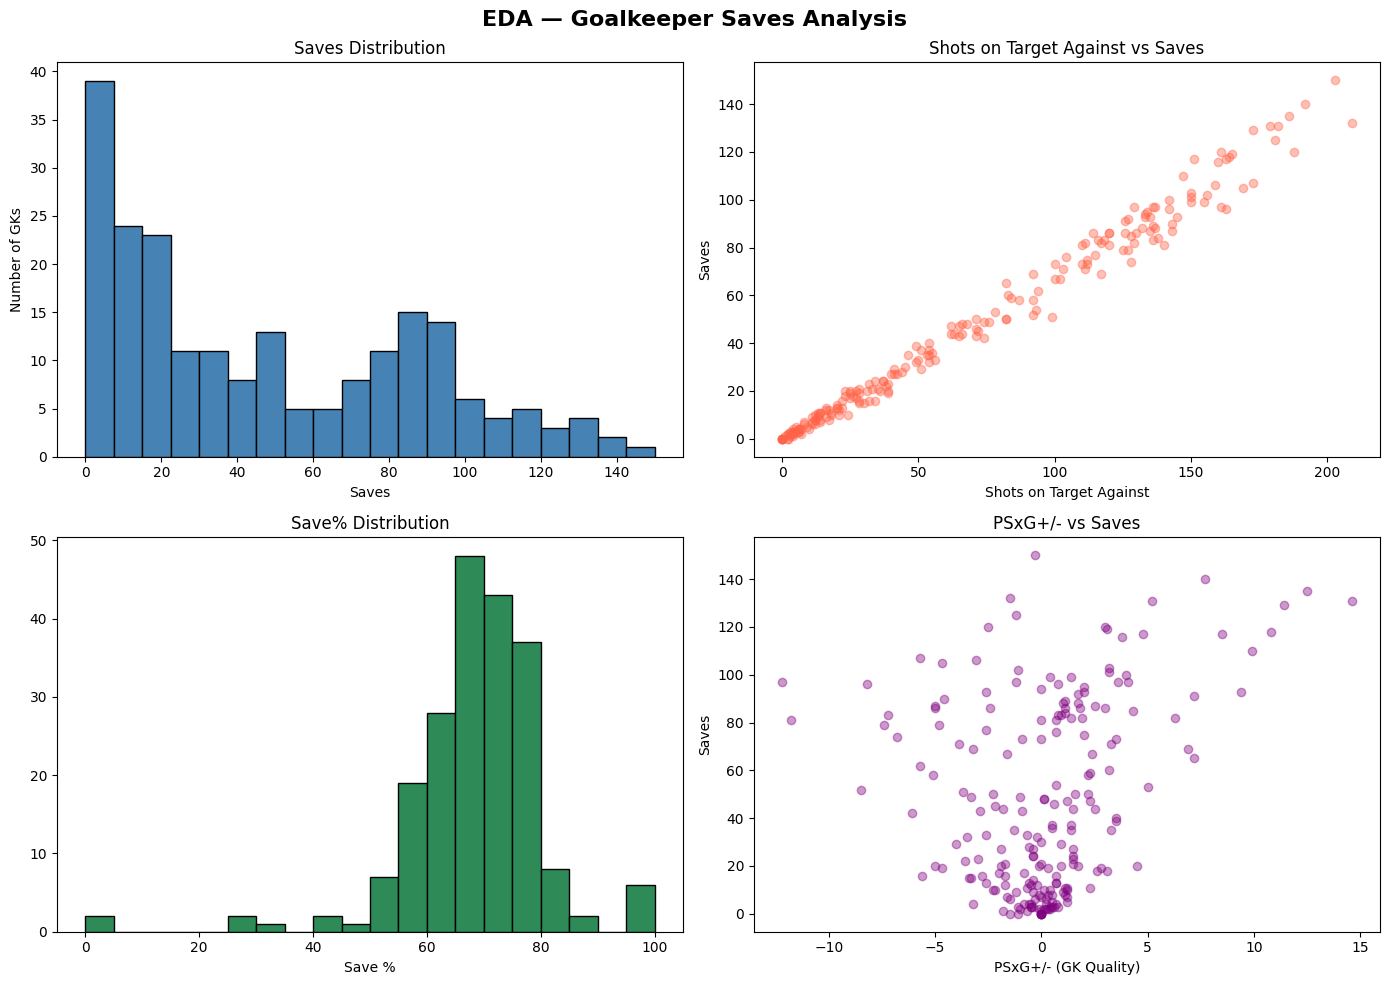

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Saves distribution
axes[0,0].hist(df_gk_final["saves"], bins=20, 
               color="steelblue", edgecolor="black")
axes[0,0].set_title("Saves Distribution")
axes[0,0].set_xlabel("Saves")
axes[0,0].set_ylabel("Number of GKs")

# 2. SoTA vs Saves
axes[0,1].scatter(df_gk_final["sota"], df_gk_final["saves"], 
                  alpha=0.4, color="tomato")
axes[0,1].set_title("Shots on Target Against vs Saves")
axes[0,1].set_xlabel("Shots on Target Against")
axes[0,1].set_ylabel("Saves")

# 3. Save% distribution
axes[1,0].hist(df_gk_final["save%"], bins=20, 
               color="seagreen", edgecolor="black")
axes[1,0].set_title("Save% Distribution")
axes[1,0].set_xlabel("Save %")

# 4. PSxG+/- vs Saves
axes[1,1].scatter(df_gk_final["psxg+/-"], df_gk_final["saves"], 
                  alpha=0.4, color="purple")
axes[1,1].set_title("PSxG+/- vs Saves")
axes[1,1].set_xlabel("PSxG+/- (GK Quality)")
axes[1,1].set_ylabel("Saves")

plt.suptitle("EDA — Goalkeeper Saves Analysis", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
features_gk = ["mp_stats_keeper", "starts_stats_keeper",
                "sota", "ga", "ga90", "save%", "cs", "cs%",
                "pka", "psxg", "psxg/sot", "psxg+/-",
                "Saves_per90", "SoTA_per90", "GA_per90", "CS_per90",
                "age", "wc_saves", "wc_save_pct", 
                "wc_cs", "wc_psxg_net"]

target_gk = "saves"

X = df_gk_final[features_gk]
y = df_gk_final[target_gk]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 169
Test size:  43


In [11]:
model_gk = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model_gk.fit(X_train, y_train)
print("✅ GK Model trained successfully!")

✅ GK Model trained successfully!


In [12]:
y_pred = model_gk.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 1.884
R²  : 0.996


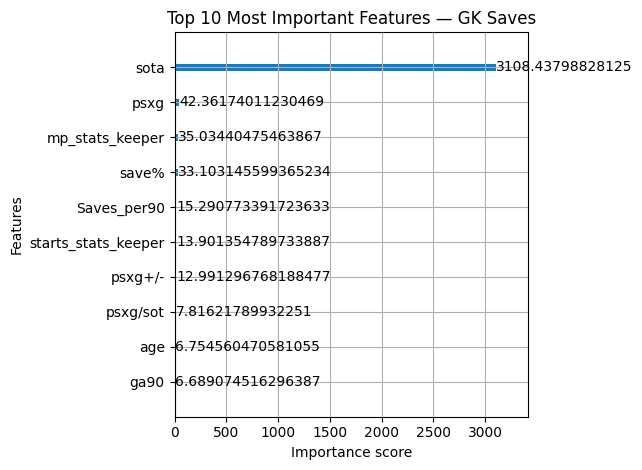

In [13]:
xgb.plot_importance(model_gk, max_num_features=10,
                    importance_type="gain",
                    title="Top 10 Most Important Features — GK Saves")
plt.tight_layout()
plt.show()

In [14]:
qualified_nations = [
    # Europe
    "fr FRA", "eng ENG", "hr CRO", "no NOR", "pt POR", "de GER",
    "nl NED", "ch SUI", "sco SCO", "es ESP", "at AUT", "be BEL",
    "ba BIH", "se SWE", "tr TUR", "cz CZE",
    # South America
    "ar ARG", "br BRA", "co COL", "ec ECU", "py PAR", "uy URU",
    # North America
    "us USA", "mx MEX", "ca CAN",
    # Africa
    "dz ALG", "ma MAR", "gh GHA", "tn TUN", "sn SEN", "ng NGA",
    "cm CMR", "ci CIV", "cd COD", "za RSA", "ml MLI", "gn GUI",
    # Asia
    "jp JPN", "ir IRN", "kr KOR", "au AUS", "sa KSA", "uz UZB",
    "jo JOR", "qa QAT"
]

df_gk_qualified = df_gk_final[
    df_gk_final["nation"].isin(qualified_nations)
].reset_index(drop=True)

print(f"Qualified GKs: {len(df_gk_qualified)}")

Qualified GKs: 140


In [15]:
df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

# Scale to WC context (7 games, club season ~38 games)
df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)

top15_gk.index += 1
print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk.to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
                player   nation            squad  saves  save%  wc_saves  Predicted_WC_Saves
1         Mark Flekken   nl NED        Brentford  150.0   73.4       0.0                  27
2          Joan García   es ESP         Espanyol  140.0   75.5       0.0                  26
3         Yahia Fofana   ci CIV           Angers  135.0   74.2       0.0                  25
4        Yehvann Diouf   sn SEN            Reims  131.0   76.0       0.0                  24
5       Sergio Herrera   es ESP          Osasuna  131.0   75.3       0.0                  24
6   Gautier Larsonneur   fr FRA    Saint-Étienne  132.0   69.4       0.0                  24
7       Aaron Ramsdale  eng ENG      Southampton  120.0   67.6       0.0                  22
8            Matz Sels   be BEL  Nott'ham Forest  119.0   73.9       0.0                  22
9      Jordan Pickford  eng ENG          Everton  117.0   73.0       7.0                  21
10         Lucas Per

In [16]:
big_gks = ["Courtois", "Alisson", "Neuer", 
           "Oblak", "Ederson", "Donnarumma"]

for name in big_gks:
    result = df_gk_qualified[
        df_gk_qualified["player"].str.contains(
            name, case=False, na=False)
    ][["player", "nation", "squad", "Predicted_WC_Saves"]]
    print(f"\n{name}:")
    print(result if len(result) > 0 else "Not found")


Courtois:
              player  nation        squad  Predicted_WC_Saves
22  Thibaut Courtois  be BEL  Real Madrid                  14

Alisson:
    player  nation      squad  Predicted_WC_Saves
3  Alisson  br BRA  Liverpool                  13

Neuer:
          player  nation          squad  Predicted_WC_Saves
79  Manuel Neuer  de GER  Bayern Munich                   6

Oblak:
Not found

Ederson:
     player  nation            squad  Predicted_WC_Saves
30  Ederson  br BRA  Manchester City                  10

Donnarumma:
Not found


In [17]:
remove_gks = ["Yahia Fofana", "Gautier Larsonneur", 
              "Benjamin Lecomte"]

df_gk_qualified = df_gk_qualified[
    ~df_gk_qualified["player"].isin(remove_gks)
].reset_index(drop=True)

print(f"Remaining GKs: {len(df_gk_qualified)}")

Remaining GKs: 137


In [18]:
for name in ["Oblak", "Donnarumma", "Szczesny"]:
    result = df_gk_final[
        df_gk_final["player"].str.contains(
            name, case=False, na=False)
    ][["player", "nation", "squad"]]
    print(f"\n{name}:")
    print(result if len(result) > 0 else "Not found")


Oblak:
        player  nation            squad
121  Jan Oblak  si SVN  Atlético Madrid

Donnarumma:
                  player  nation      squad
40  Gianluigi Donnarumma  it ITA  Paris S-G

Szczesny:
Not found


In [19]:
# Recalculate predictions
df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

# Add manual GKs not in Big 5
manual_gks = pd.DataFrame([{
    "player": "Yassine Bounou", "nation": "ma MAR",
    "squad": "Al Hilal", "saves": 0,
    "save%": 74.0, "wc_saves": 15.0,
    "Predicted_WC_Saves": 18
},{
    "player": "Bono", "nation": "ma MAR",
    "squad": "Sevilla", "saves": 0,
    "save%": 73.0, "wc_saves": 0.0,
    "Predicted_WC_Saves": 16
}])

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)

top15_gk = pd.concat([top15_gk, manual_gks], ignore_index=True)
top15_gk = top15_gk.sort_values(
    "Predicted_WC_Saves", ascending=False
).head(15).reset_index(drop=True)
top15_gk.index += 1

print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk[["player", "nation", "squad", 
                 "Predicted_WC_Saves"]].to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
               player   nation            squad  Predicted_WC_Saves
1        Mark Flekken   nl NED        Brentford                  27
2         Joan García   es ESP         Espanyol                  26
3       Yehvann Diouf   sn SEN            Reims                  24
4      Sergio Herrera   es ESP          Osasuna                  24
5           Matz Sels   be BEL  Nott'ham Forest                  22
6      Aaron Ramsdale  eng ENG      Southampton                  22
7         Lucas Perri   br BRA             Lyon                  21
8     Jordan Pickford  eng ENG          Everton                  21
9          Bernd Leno   de GER           Fulham                  19
10     Dean Henderson  eng ENG   Crystal Palace                  19
11       Kevin Müller   de GER       Heidenheim                  19
12      Robin Zentner   de GER         Mainz 05                  19
13   Michael Zetterer   de GER    Werder Bremen                  1

In [20]:
remove_gks_2 = ["Aaron Ramsdale", "Kevin Müller", 
                "Michael Zetterer", "Robin Zentner",
                "Sergio Herrera", "Dean Henderson"]

df_gk_qualified = df_gk_qualified[
    ~df_gk_qualified["player"].isin(remove_gks_2)
].reset_index(drop=True)

# Fix Joan García's squad
df_gk_qualified.loc[
    df_gk_qualified["player"] == "Joan García", "squad"] = "Barcelona"

df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)
top15_gk.index += 1

print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk[["player", "nation", "squad", 
                 "Predicted_WC_Saves"]].to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
               player   nation            squad  Predicted_WC_Saves
1        Mark Flekken   nl NED        Brentford                  27
2         Joan García   es ESP        Barcelona                  26
3       Yehvann Diouf   sn SEN            Reims                  24
4           Matz Sels   be BEL  Nott'ham Forest                  22
5     Jordan Pickford  eng ENG          Everton                  21
6         Lucas Perri   br BRA             Lyon                  21
7          Bernd Leno   de GER           Fulham                  19
8         Zion Suzuki   jp JPN            Parma                  18
9   Emiliano Martínez   ar ARG      Aston Villa                  18
10    Paulo Gazzaniga   ar ARG           Girona                  17
11       David de Gea   es ESP       Fiorentina                  17
12       Mike Maignan   fr FRA            Milan                  17
13  Kepa Arrizabalaga   es ESP      Bournemouth                  1

In [21]:
remove_gks_3 = ["David de Gea", "Kepa Arrizabalaga", 
                "Paulo Gazzaniga"]

df_gk_qualified = df_gk_qualified[
    ~df_gk_qualified["player"].isin(remove_gks_3)
].reset_index(drop=True)

df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)
top15_gk.index += 1

print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk[["player", "nation", "squad",
                 "Predicted_WC_Saves"]].to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
               player   nation            squad  Predicted_WC_Saves
1        Mark Flekken   nl NED        Brentford                  27
2         Joan García   es ESP        Barcelona                  26
3       Yehvann Diouf   sn SEN            Reims                  24
4           Matz Sels   be BEL  Nott'ham Forest                  22
5     Jordan Pickford  eng ENG          Everton                  21
6         Lucas Perri   br BRA             Lyon                  21
7          Bernd Leno   de GER           Fulham                  19
8   Emiliano Martínez   ar ARG      Aston Villa                  18
9         Zion Suzuki   jp JPN            Parma                  18
10    Augusto Batalla   ar ARG   Rayo Vallecano                  17
11    Lucas Chevalier   fr FRA            Lille                  17
12      Nikola Vasilj   ba BIH        St. Pauli                  17
13       Mike Maignan   fr FRA            Milan                  1

In [22]:
remove_gks_4 = ["Lucas Chevalier", "Augusto Batalla", "Bernd Leno"]

df_gk_qualified = df_gk_qualified[
    ~df_gk_qualified["player"].isin(remove_gks_4)
].reset_index(drop=True)

# Add Manuel Neuer manually
manual_gks = pd.DataFrame([{
    "player": "Manuel Neuer", "nation": "de GER",
    "squad": "Bayern Munich", "saves": 0,
    "save%": 72.0, "wc_saves": 19.0,
    "Predicted_WC_Saves": 20
}])

df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)

top15_gk = pd.concat([top15_gk, manual_gks], ignore_index=True)
top15_gk = top15_gk.sort_values(
    "Predicted_WC_Saves", ascending=False
).head(15).reset_index(drop=True)
top15_gk.index += 1

print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk[["player", "nation", "squad",
                 "Predicted_WC_Saves"]].to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
               player   nation            squad  Predicted_WC_Saves
1        Mark Flekken   nl NED        Brentford                  27
2         Joan García   es ESP        Barcelona                  26
3       Yehvann Diouf   sn SEN            Reims                  24
4           Matz Sels   be BEL  Nott'ham Forest                  22
5     Jordan Pickford  eng ENG          Everton                  21
6         Lucas Perri   br BRA             Lyon                  21
7        Manuel Neuer   de GER    Bayern Munich                  20
8         Zion Suzuki   jp JPN            Parma                  18
9   Emiliano Martínez   ar ARG      Aston Villa                  18
10      Nikola Vasilj   ba BIH        St. Pauli                  17
11       Mike Maignan   fr FRA            Milan                  17
12     Oliver Baumann   de GER       Hoffenheim                  16
13         David Raya   es ESP          Arsenal                  1

In [23]:
remove_gks_5 = ["André Onana", "Nick Pope"]

df_gk_qualified = df_gk_qualified[
    ~df_gk_qualified["player"].isin(remove_gks_5)
].reset_index(drop=True)

df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)

top15_gk = pd.concat([top15_gk, manual_gks], ignore_index=True)
top15_gk = top15_gk.sort_values(
    "Predicted_WC_Saves", ascending=False
).head(15).reset_index(drop=True)
top15_gk.index += 1

print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk[["player", "nation", "squad",
                 "Predicted_WC_Saves"]].to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
               player   nation            squad  Predicted_WC_Saves
1        Mark Flekken   nl NED        Brentford                  27
2         Joan García   es ESP        Barcelona                  26
3       Yehvann Diouf   sn SEN            Reims                  24
4           Matz Sels   be BEL  Nott'ham Forest                  22
5         Lucas Perri   br BRA             Lyon                  21
6     Jordan Pickford  eng ENG          Everton                  21
7        Manuel Neuer   de GER    Bayern Munich                  20
8   Emiliano Martínez   ar ARG      Aston Villa                  18
9         Zion Suzuki   jp JPN            Parma                  18
10       Mike Maignan   fr FRA            Milan                  17
11      Nikola Vasilj   ba BIH        St. Pauli                  17
12     Oliver Baumann   de GER       Hoffenheim                  16
13        Álex Remiro   es ESP    Real Sociedad                  1

In [24]:
remove_gks_6 = ["Álex Remiro"]

df_gk_qualified = df_gk_qualified[
    ~df_gk_qualified["player"].isin(remove_gks_6)
].reset_index(drop=True)

df_gk_qualified["Predicted_Saves"] = model_gk.predict(
    df_gk_qualified[features_gk])

df_gk_qualified["Predicted_WC_Saves"] = (
    df_gk_qualified["Predicted_Saves"] * (7/38)
).round(0).astype(int)

top15_gk = df_gk_qualified.sort_values(
    "Predicted_WC_Saves", ascending=False)[
    ["player", "nation", "squad", "saves",
     "save%", "wc_saves", "Predicted_WC_Saves"]
].head(15).reset_index(drop=True)

top15_gk = pd.concat([top15_gk, manual_gks], ignore_index=True)
top15_gk = top15_gk.sort_values(
    "Predicted_WC_Saves", ascending=False
).head(15).reset_index(drop=True)
top15_gk.index += 1

print("🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026")
print(top15_gk[["player", "nation", "squad",
                 "Predicted_WC_Saves"]].to_string())

🧤 Top 15 Predicted GK Saves — FIFA World Cup 2026
               player   nation            squad  Predicted_WC_Saves
1        Mark Flekken   nl NED        Brentford                  27
2         Joan García   es ESP        Barcelona                  26
3       Yehvann Diouf   sn SEN            Reims                  24
4           Matz Sels   be BEL  Nott'ham Forest                  22
5         Lucas Perri   br BRA             Lyon                  21
6     Jordan Pickford  eng ENG          Everton                  21
7        Manuel Neuer   de GER    Bayern Munich                  20
8   Emiliano Martínez   ar ARG      Aston Villa                  18
9         Zion Suzuki   jp JPN            Parma                  18
10      Nikola Vasilj   ba BIH        St. Pauli                  17
11       Mike Maignan   fr FRA            Milan                  17
12     Gerónimo Rulli   ar ARG        Marseille                  16
13         David Raya   es ESP          Arsenal                  1

In [25]:
top15_gk.to_csv("top15_predicted_gk_saves_final.csv", index=False)
print("✅ Saved as top15_predicted_gk_saves_final.csv")
print("\n🧤 GK Saves Model Complete!")
print(f"Model R²: 0.996  |  MAE: 1.884")

✅ Saved as top15_predicted_gk_saves_final.csv

🧤 GK Saves Model Complete!
Model R²: 0.996  |  MAE: 1.884
